# Phase 6 : visualisation et storytelling

Projet final Machine Learning, blocs 6 et 8.

## Objectif de ce notebook

La phase 5 a produit des réponses. Celle-ci les rend transmissibles. Les figures de la phase 5
étaient des outils d'analyse, faites pour trancher une question. Celles-ci sont des outils de
communication, faites pour qu'un coach ou un producteur comprenne en cinq secondes.

La différence n'est pas cosmétique. Un titre de phase 5 dit ce que la figure montre, un titre
de phase 6 dit ce qu'il faut en retenir.

## Le fil rouge

Une seule histoire tient l'ensemble, et elle se résume en une phrase.

> **Tous les avantages précoces ne se valent pas, et le classement auquel tout le monde se fie
> est presque exactement à l'envers.**

Elle se déroule en quatre actes.

| Acte | Question | Ce que le lecteur découvre |
|---|---|---|
| Contexte | Que sait-on à la 15e minute ? | L'or explique beaucoup, mais pas tout |
| Tension | Quels avantages comptent vraiment ? | Le classement brut est trompeur |
| Révélation | Que reste-t-il à or égal ? | Le premier héraut vaut zéro, le dragon vaut 1 030 or |
| Résolution | Où se joue alors la partie ? | Dans les 29 % de parties serrées, pas ailleurs |

## Les règles de design retenues

Le guide en donne cinq. Trois demandent une décision explicite sur ce projet.

**Honnêteté des axes.** Toute barre part de zéro. Quand un écart de deux points devient
illisible à cette échelle, la variable est représentée comme un **écart au hasard**, centré sur
zéro, plutôt que par une barre tronquée. C'est le cas de l'avantage du côté bleu.

**Focus.** Gris ardoise pour le contexte, brique sourde pour l'élément à regarder. Une seule
couleur d'accent par figure, jamais deux.

**Source et période sur chaque figure.** Ajoutées par `src/viz.py::signer`, pas à la main : une
légende recopiée neuf fois est une légende fausse une fois.

## Périmètre

Comme en phase 5, tout est calculé sur les saisons 2022 à 2025. La saison 2026 reste fermée
jusqu'à la fin de la phase 7.

## Livrables

Neuf figures dans `figures/`, préfixées `06_`, et leur documentation dans
`docs/visualisations.md`.

Données fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).

## 0. Chargement, style et agrégats

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import analyse, config, viz

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

viz.appliquer_style()
PALETTE = viz.PALETTE

donnees = pd.read_parquet(config.DATA_PROCESSED / "lol_at15.parquet")
train = donnees[donnees["date"] < config.SPLIT_DATE].copy()


# Les figures sont lues en francais : 13,6 est un nombre, 13.6 est une coquille.
# Les deux formateurs vivent dans src/viz.py pour que texte et figures s'accordent.
fr = viz.entier_fr
nb = viz.nombre_fr

print(f"Perimetre : {fr(len(train))} lignes, {fr(train['gameid'].nunique())} parties")
print(f"Periode   : {train['date'].min():%Y-%m-%d} au {train['date'].max():%Y-%m-%d}")
print(f"Figures   : {config.FIGURES}")

Perimetre : 76 070 lignes, 38 035 parties
Periode   : 2022-01-10 au 2025-12-29
Figures   : E:\LWP(LoLWinPrediciton)\lol-win-prediction\figures


Les agrégats sont calculés une fois ici, pas dans les cellules de figure. Une cellule de figure
qui recalcule ses propres chiffres finit par en afficher de différents de ceux du texte.

In [2]:
# Reference commune : la pente de conversion de l'or, qui sert de convertisseur partout.
pente, courbe = analyse.pente_or(train)
bande500 = train[train["golddiffat15"].abs() < 500]

# Acte 1 : le classement brut des avantages.
AVANTAGES = ["golddiffat15", "xpdiffat15", "csdiffat15", "diff_kills_at15",
             "deathsat15", "objectifs_precoces", "firstherald", "firstblood",
             "firstdragon", "forme_equipe_10_derniers"]
classement = analyse.pouvoir_discriminant(train, AVANTAGES)

# Acte 2 : le meme objectif, mesure deux fois. Brut, puis a or egal.
lignes = []
for objectif in config.EARLY_OBJECTIVES:
    brut = (train.loc[train[objectif] == 1, "result"].mean()
            - train.loc[train[objectif] == 0, "result"].mean())
    propre = analyse.valeur_en_or(train, objectif, pente)
    lignes.append({
        "objectif": objectif,
        "ecart_brut": 100 * brut,
        "ecart_a_or_egal": propre["ecart_points"],
        "or_equivalent": propre["or_equivalent"],
        "p_valeur": propre["p_valeur"],
    })
contraste = pd.DataFrame(lignes).sort_values("ecart_brut", ascending=False)
print(contraste.round(2).to_string(index=False))

   objectif  ecart_brut  ecart_a_or_egal  or_equivalent  p_valeur
firstherald       22.93             0.88          64.44      0.51
 firstblood       19.89             0.39          28.35      0.77
firstdragon       17.08            14.06        1031.03      0.00


In [3]:
# Acte 4 : les trois regimes de partie, definis sur l'ecart d'or a la 15e minute.
SEUIL_SERRE, SEUIL_LARGE = 1000, 3000
ecart = train["golddiffat15"].abs()
train["regime"] = np.select(
    [ecart < SEUIL_SERRE, ecart < SEUIL_LARGE],
    ["Serrée", "Intermédiaire"],
    default="Large",
)
ORDRE_REGIMES = ["Serrée", "Intermédiaire", "Large"]

regimes = []
for nom in ORDRE_REGIMES:
    sous = train[train["regime"] == nom]
    devant = sous[sous["golddiffat15"] > 0]
    regimes.append({
        "regime": nom,
        "part_pct": 100 * len(sous) / len(train),
        "lignes": len(sous),
        "taux_du_camp_en_avance": 100 * devant["result"].mean(),
    })
regimes = pd.DataFrame(regimes)
print(regimes.round(1).to_string(index=False))

       regime  part_pct  lignes  taux_du_camp_en_avance
       Serrée      29.2   22232                    56.8
Intermédiaire      42.5   32354                    73.7
        Large      28.2   21484                    91.8


In [4]:
# Questions 2 a 5, agregats deja valides en phase 5.
bleu = train[train["side"] == "Blue"]
bleu_saison = analyse.taux_victoire(bleu, "saison")
bleu_region = analyse.taux_victoire(bleu, "region")
bleu_region = bleu_region[bleu_region["fiable"]].sort_values("taux")
ic_bas, ic_haut = analyse.intervalle_wilson(int(bleu["result"].sum()), len(bleu))

COMPOS = ["compo_nb_tank", "compo_nb_mage", "compo_nb_marksman", "compo_nb_fighter"]
compo_tables = {c: analyse.taux_victoire(bande500, c, effectif_minimum=300)
                for c in COMPOS}

TRANCHES = [0, 0.3, 0.5, 0.7, 1.0]
ETIQUETTES = ["moins de 30 %", "30 a 50 %", "50 a 70 %", "plus de 70 %"]
REGIMES_FORME = {
    "Avance, or > 1 000": train[train["golddiffat15"] > 1000],
    "Partie équilibrée, |or| < 500": bande500,
    "Retard, or < -1 000": train[train["golddiffat15"] < -1000],
}
forme_tables = {}
for nom, sous in REGIMES_FORME.items():
    decoupe = pd.cut(sous["forme_equipe_10_derniers"], TRANCHES,
                     labels=ETIQUETTES, include_lowest=True)
    forme_tables[nom] = analyse.taux_victoire(sous.assign(forme=decoupe), "forme")

avance = train[train["golddiffat15"] > 1000]
retard = train[train["golddiffat15"] < -1000]
conversion = analyse.taux_victoire(avance, "tier_ligue")
remontee = analyse.taux_victoire(retard, "tier_ligue")
tier1, tier3 = avance[avance["tier_ligue"] == 1], avance[avance["tier_ligue"] == 3]
test_tiers = analyse.test_deux_proportions(
    int(tier1["result"].sum()), len(tier1), int(tier3["result"].sum()), len(tier3)
)

print("Agregats prets.")
print(f"  cote bleu : {100 * bleu['result'].mean():.2f} % "
      f"[{100 * ic_bas:.2f} ; {100 * ic_haut:.2f}]")
print(f"  tiers     : p = {test_tiers['p_valeur']:.3f}")

Agregats prets.
  cote bleu : 52.93 % [52.43 ; 53.43]
  tiers     : p = 0.558


## 1. Vue d'ensemble : le tableau de bord

**Message.** Quatre chiffres à retenir, et la relation qui structure tout le projet.

**Audience.** Direction sportive, producteur, quelqu'un qui ne lira rien d'autre.

Le guide limite un tableau de bord à six ou huit éléments visuels. Celui-ci en compte six :
quatre tuiles d'indicateurs, la courbe de conversion et la répartition des parties. Les
indicateurs sont en haut, le graphique principal en bas à gauche, le secondaire à droite, ce
qui suit la lecture naturelle en Z.

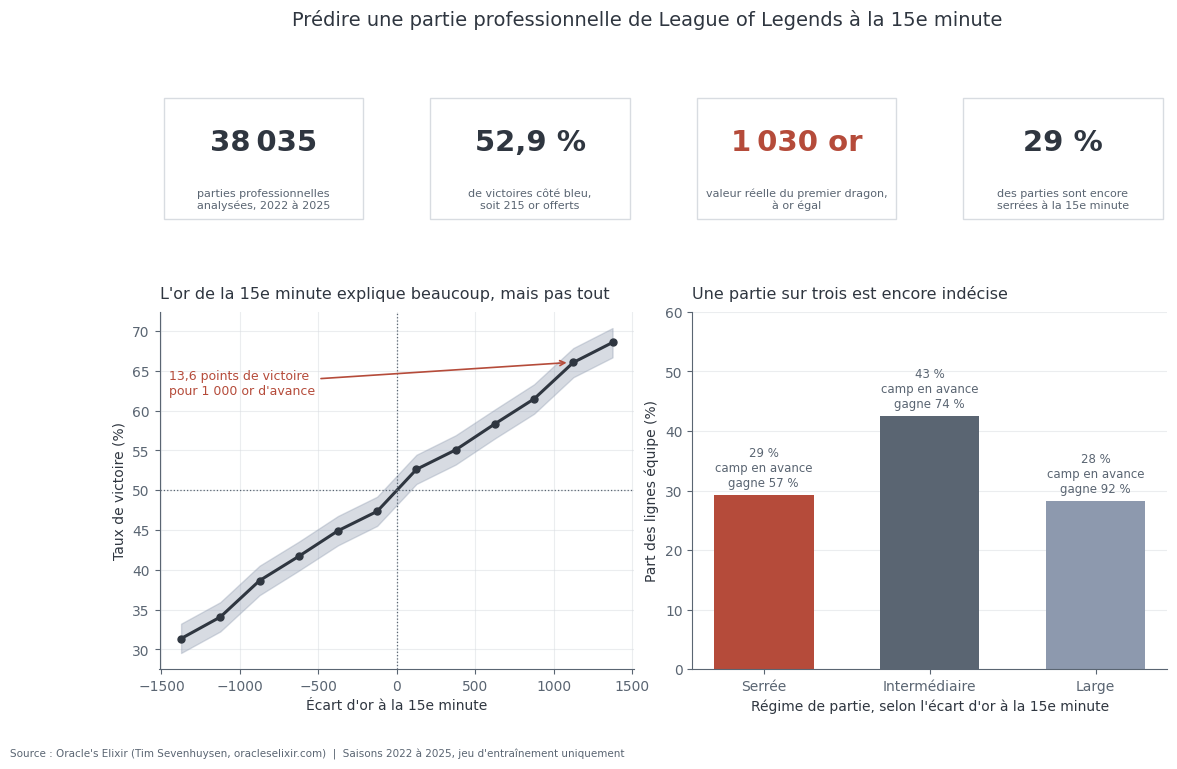

In [5]:
fig = plt.figure(figsize=(13, 7.5))
grille = GridSpec(2, 4, figure=fig, height_ratios=[0.9, 2.4], hspace=0.35, wspace=0.28)

or_dragon = contraste.loc[contraste["objectif"] == "firstdragon", "or_equivalent"].iloc[0]

# Ligne 1 : les quatre chiffres a retenir.
kpi = [
    (fr(train["gameid"].nunique()), "parties professionnelles\nanalysées, 2022 à 2025", False),
    (f"{nb(100 * bleu['result'].mean())} %",
     f"de victoires côté bleu,\nsoit {fr((bleu['result'].mean() - 0.5) / pente)} or offerts",
     False),
    (f"{fr(round(or_dragon, -1))} or", "valeur réelle du premier dragon,\nà or égal", True),
    (f"{nb(regimes.loc[0, 'part_pct'], 0)} %",
     "des parties sont encore\nserrées à la 15e minute", False),
]
for colonne, (valeur, libelle, accent) in enumerate(kpi):
    viz.tuile_kpi(fig.add_subplot(grille[0, colonne]), valeur, libelle, accent=accent)

# Ligne 2 gauche : la relation centrale du projet.
ax = fig.add_subplot(grille[1, :2])
ax.fill_between(courbe["milieu"], 100 * courbe["ic_bas"], 100 * courbe["ic_haut"],
                color=PALETTE["accent"], alpha=0.35)
ax.plot(courbe["milieu"], 100 * courbe["taux"], marker="o", markersize=5,
        color=PALETTE["primary"], linewidth=2.2)
ax.axhline(50, color=PALETTE["secondary"], linestyle=":", linewidth=0.9)
ax.axvline(0, color=PALETTE["secondary"], linestyle=":", linewidth=0.9)
ax.annotate(f"{nb(100 * pente * 1000)} points de victoire\npour 1 000 or d'avance",
            xy=(1100, 100 * courbe["taux"].iloc[-2]), xytext=(-1450, 62),
            fontsize=9, color=PALETTE["highlight"],
            arrowprops={"arrowstyle": "->", "color": PALETTE["highlight"], "lw": 1.2})
ax.set_xlabel("Écart d'or à la 15e minute")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("L'or de la 15e minute explique beaucoup, mais pas tout",
             fontsize=11.5, pad=10, loc="left")
ax.grid(True, alpha=0.5)

# Ligne 2 droite : et la partie n'est jouee que dans un cas sur trois.
ax = fig.add_subplot(grille[1, 2:])
couleurs = [PALETTE["highlight"], PALETTE["secondary"], PALETTE["accent"]]
barres = ax.bar(regimes["regime"], regimes["part_pct"], color=couleurs, width=0.6)
for barre, (_, ligne) in zip(barres, regimes.iterrows()):
    ax.text(barre.get_x() + barre.get_width() / 2, ligne["part_pct"] + 1.5,
            f"{nb(ligne['part_pct'], 0)} %\ncamp en avance\n"
            f"gagne {nb(ligne['taux_du_camp_en_avance'], 0)} %",
            ha="center", fontsize=8.5, color=PALETTE["secondary"])
ax.set_ylim(0, 60)
ax.set_ylabel("Part des lignes équipe (%)")
ax.set_xlabel("Régime de partie, selon l'écart d'or à la 15e minute")
ax.set_title("Une partie sur trois est encore indécise", fontsize=11.5, pad=10, loc="left")
ax.grid(True, axis="y", alpha=0.5)

fig.suptitle("Prédire une partie professionnelle de League of Legends à la 15e minute",
             fontsize=14, y=0.99)
viz.signer(fig, y=0.005)
viz.enregistrer(fig, "06_tableau_de_bord.png")
plt.show()

Le tableau de bord pose les deux faits qui cadrent tout le reste. L'or de la 15e minute porte
un signal fort et régulier, environ 13,6 points de taux de victoire pour 1 000 or. Et pourtant
une ligne sur trois appartient à une partie encore serrée, où le camp qui mène ne gagne que
57 % du temps. C'est là que se joue la valeur d'un modèle, et c'est là que la suite regarde.

## 2. Acte 1 : le classement auquel tout le monde se fie

**Message.** Voici les avantages de la 15e minute, rangés par leur pouvoir de discrimination
mesuré isolément.

**Audience.** Analyste, casteur.

Barres horizontales triées : c'est le graphique de classement recommandé par le guide au-delà
de cinq catégories. L'axe part de zéro comme demandé, et une ligne de référence marque 0,50,
la valeur d'un tirage à pile ou face.

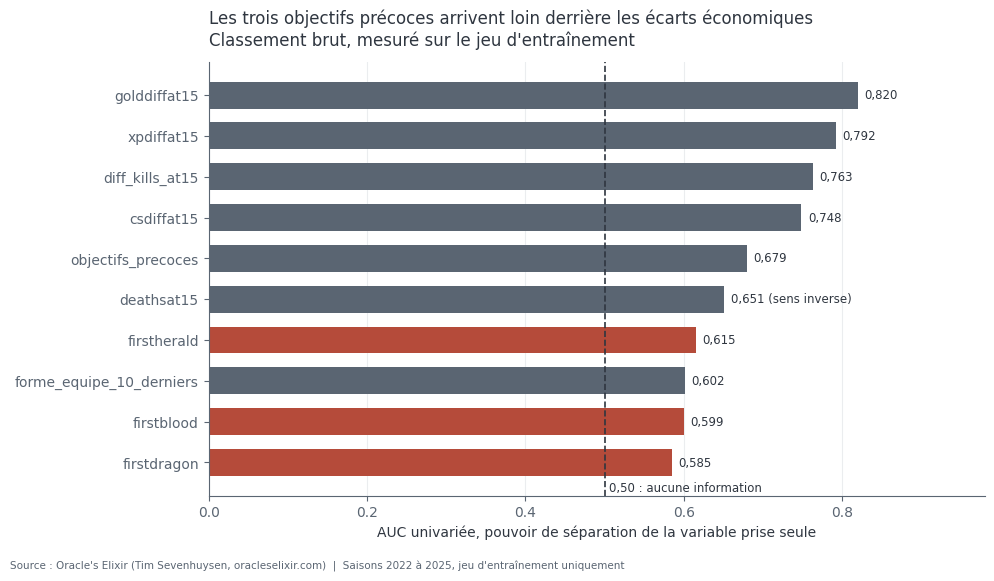

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.6))

ordre = classement.sort_values("auc_univarie")
est_objectif = ordre["feature"].isin(config.EARLY_OBJECTIVES)
couleurs = np.where(est_objectif, PALETTE["highlight"], PALETTE["secondary"])

ax.barh(ordre["feature"], ordre["auc_univarie"], color=couleurs, height=0.66)
for y, (valeur, sens) in enumerate(zip(ordre["auc_univarie"], ordre["sens"])):
    suffixe = " (sens inverse)" if sens == "negatif" else ""
    ax.text(valeur + 0.008, y, f"{nb(valeur, 3)}{suffixe}", va="center", fontsize=8.5,
            color=PALETTE["primary"])

ax.axvline(0.5, color=PALETTE["primary"], linestyle="--", linewidth=1.2)
ax.text(0.505, -0.72, "0,50 : aucune information", fontsize=8.5, color=PALETTE["primary"])
ax.set_xlim(0, 0.98)
ax.set_xlabel("AUC univariée, pouvoir de séparation de la variable prise seule")
ax.set_title("Les trois objectifs précoces arrivent loin derrière les écarts économiques\n"
             "Classement brut, mesuré sur le jeu d'entraînement",
             fontsize=12, pad=12, loc="left")
ax.grid(True, axis="x", alpha=0.5)

fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "06_hierarchie_avantages.png")
plt.show()

Lu tel quel, ce classement dit que les objectifs neutres, en brique, comptent peu : entre 0,58
et 0,61 contre 0,82 pour l'écart d'or. C'est la lecture habituelle, et l'acte suivant montre
qu'elle est fausse pour l'un des trois.

## 3. Acte 2 : la même mesure, à avantage économique égal

**Message.** Le classement brut des objectifs est presque exactement à l'envers.

**Audience.** Coach, analyste. C'est la figure à mettre en ouverture de la soutenance.

Barres groupées, technique du contraste : la même quantité mesurée de deux façons, côte à côte.
Le lecteur n'a rien à calculer, il voit une barre s'effondrer et une autre tenir.

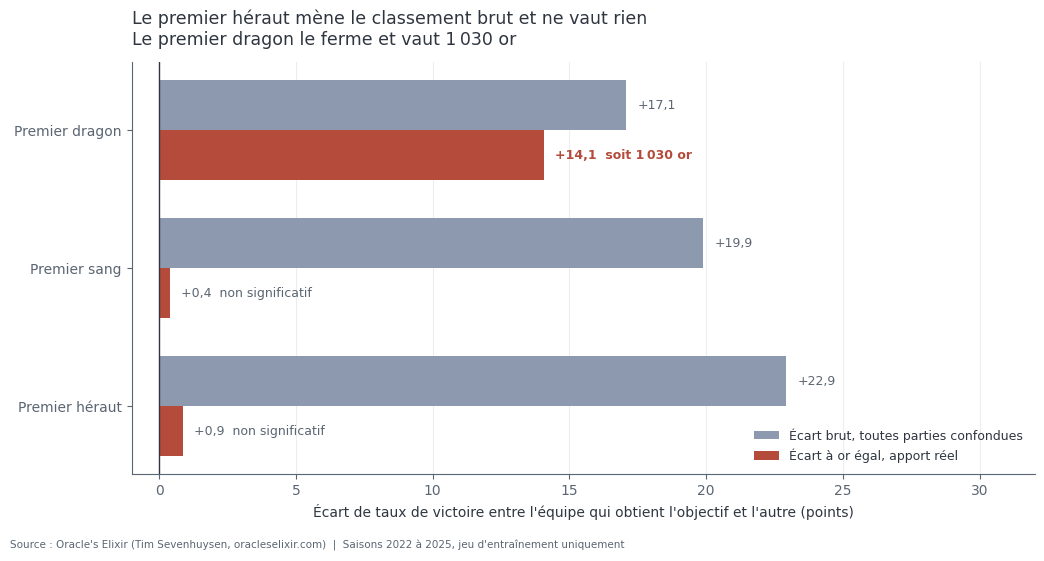

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))

y = np.arange(len(contraste))
hauteur = 0.36
ax.barh(y + hauteur / 2, contraste["ecart_brut"], hauteur,
        color=PALETTE["accent"], label="Écart brut, toutes parties confondues")
ax.barh(y - hauteur / 2, contraste["ecart_a_or_egal"], hauteur,
        color=PALETTE["highlight"], label="Écart à or égal, apport réel")

LIBELLES = {"firstherald": "Premier héraut", "firstblood": "Premier sang",
            "firstdragon": "Premier dragon"}
ax.set_yticks(y)
ax.set_yticklabels([LIBELLES[o] for o in contraste["objectif"]])

for i, (_, ligne) in enumerate(contraste.iterrows()):
    ax.text(ligne["ecart_brut"] + 0.4, i + hauteur / 2,
            nb(ligne["ecart_brut"], signe=True),
            va="center", fontsize=9, color=PALETTE["secondary"])
    significatif = ligne["p_valeur"] < 0.05
    ecart = nb(ligne["ecart_a_or_egal"], signe=True)
    texte = (f"{ecart}  soit {fr(round(ligne['or_equivalent'], -1))} or"
             if significatif else f"{ecart}  non significatif")
    ax.text(ligne["ecart_a_or_egal"] + 0.4, i - hauteur / 2, texte,
            va="center", fontsize=9, fontweight="bold" if significatif else "normal",
            color=PALETTE["highlight"] if significatif else PALETTE["secondary"])

ax.axvline(0, color=PALETTE["primary"], linewidth=1)
ax.set_xlim(-1, 32)
ax.set_xlabel("Écart de taux de victoire entre l'équipe qui obtient l'objectif et l'autre "
              "(points)")
ax.set_title("Le premier héraut mène le classement brut et ne vaut rien\n"
             f"Le premier dragon le ferme et vaut {fr(round(or_dragon, -1))} or",
             fontsize=12.5, pad=12, loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(True, axis="x", alpha=0.5)

fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "06_illusion_des_objectifs.png")
plt.show()

### Pourquoi l'inversion

La mécanique du jeu explique la figure entièrement.

Le premier sang rapporte 400 or à celui qui tue. Le premier héraut se transforme en plaques de
tourelle, donc en or lui aussi. Ces deux avantages sont déjà **comptés dans l'écart d'or** :
une fois cet écart neutralisé, il ne reste rien, et les p-valeurs le confirment, 0,77 et 0,51.

Le premier dragon ne rapporte aucun or. Il donne un bonus permanent qui se cumule, et un
contrôle de la moitié inférieure de la carte. Rien de tout cela n'apparaît dans `golddiffat15`,
et c'est pourquoi ses 14,1 points survivent au contrôle, avec une p-valeur de l'ordre de
10 puissance moins 26.

**Recommandation.** Un premier sang payé d'une position sur la carte est un mauvais échange. Un
dragon sécurisé au prix de 1 000 or est un échange à l'équilibre. Pour un affichage temps réel,
c'est le dragon qu'il faut montrer, pas le premier sang.

## 4. Acte 3 : ce qui ne compte pas

Deux résultats négatifs, qui valent autant que les positifs parce qu'ils désamorcent deux idées
reçues coûteuses.

### 4.1 La composition de draft, question business 3

**Message.** À avantage économique égal, compter les tanks ne prédit rien.

Petits multiples en points avec intervalles de confiance, pas en barres : ce qu'il faut lire ici
est le chevauchement des intervalles avec la ligne des 50 %, pas la hauteur d'une colonne.

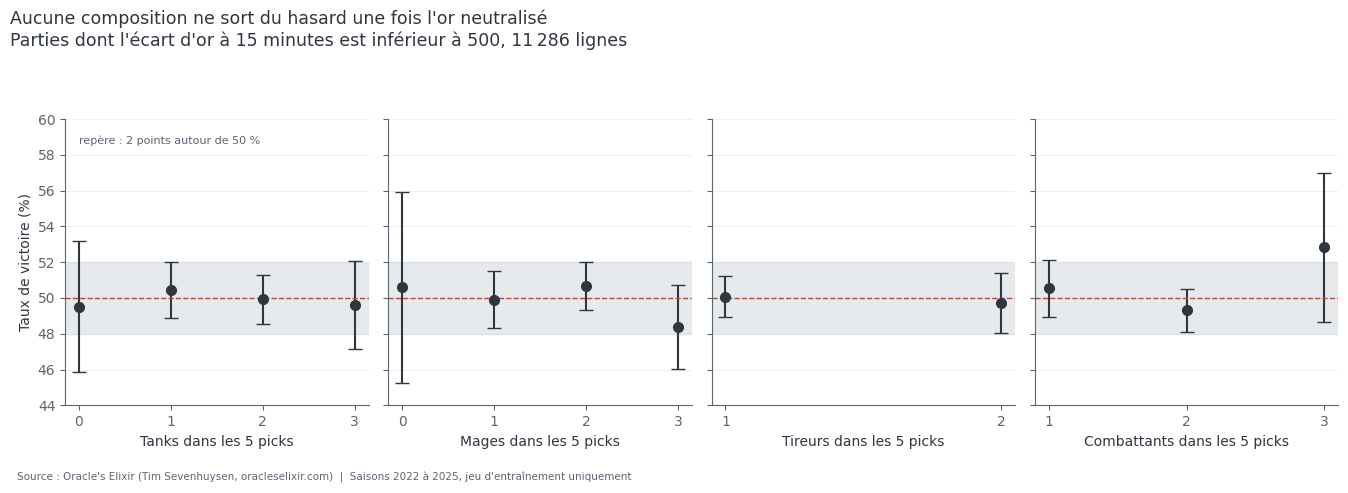

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.2), sharey=True)

TITRES = {"compo_nb_tank": "Tanks", "compo_nb_mage": "Mages",
          "compo_nb_marksman": "Tireurs", "compo_nb_fighter": "Combattants"}

for ax, colonne in zip(axes, COMPOS):
    table = compo_tables[colonne]
    table = table[table["fiable"]]
    x = table.index.astype(int)
    ax.axhspan(48, 52, color=PALETTE["grid"], alpha=0.6, zorder=0)
    ax.errorbar(x, 100 * table["taux"],
                yerr=100 * (table["ic_haut"] - table["ic_bas"]) / 2,
                marker="o", markersize=7, linestyle="none", capsize=5,
                color=PALETTE["primary"])
    ax.axhline(50, color=PALETTE["highlight"], linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xlabel(f"{TITRES[colonne]} dans les 5 picks")
    ax.set_ylim(44, 60)
    ax.grid(True, axis="y", alpha=0.45)

axes[0].set_ylabel("Taux de victoire (%)")
# Le bandeau est un repere de lecture, pas un test : ce qui compte est qu'un intervalle
# croise la ligne des 50 %, et ils la croisent tous.
axes[0].text(axes[0].get_xlim()[0] + 0.15, 58.6, "repère : 2 points autour de 50 %",
             ha="left", fontsize=8, color=PALETTE["secondary"])

fig.suptitle("Aucune composition ne sort du hasard une fois l'or neutralisé\n"
             "Parties dont l'écart d'or à 15 minutes est inférieur à 500, "
             f"{fr(len(bande500))} lignes",
             fontsize=12.5, y=1.08, x=0.005, ha="left")
fig.tight_layout()
viz.signer(fig, y=-0.02)
viz.enregistrer(fig, "06_composition_sans_effet.png")
plt.show()

Tous les intervalles croisent la ligne des 50 %. Le point le plus haut, les compositions à trois
combattants, tient sur 547 parties et son intervalle va de 48,7 % à 57,0 % : parfaitement
compatible avec le hasard.

La conclusion honnête n'est pas que la draft est sans importance, c'est que **cette
représentation de la draft**, un comptage de tags Data Dragon, n'en capte rien. La synergie et
l'ordre des picks, absents d'Oracle's Elixir, sont hors de portée.

### 4.2 Le niveau de ligue, question business 5

**Message.** Une ligue majeure ne ferme pas mieux ses parties qu'une ligue mineure.

Barres groupées partant de zéro, avec les intervalles de confiance, et l'absence de différence
écrite dans le titre plutôt que laissée à déduire.

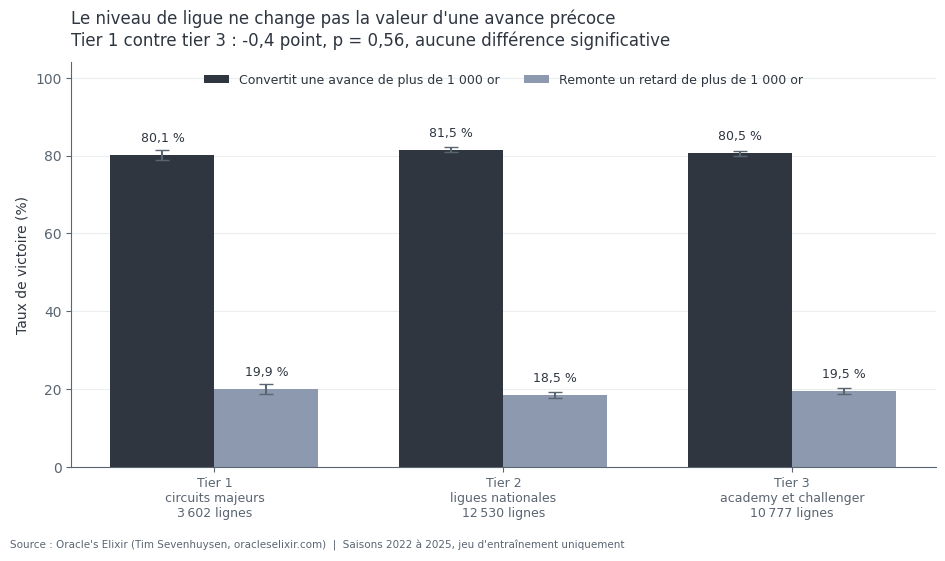

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))

tiers = conversion.index.astype(int)
x = np.arange(len(tiers))
largeur = 0.36

ax.bar(x - largeur / 2, 100 * conversion["taux"], largeur, color=PALETTE["primary"],
       yerr=100 * (conversion["ic_haut"] - conversion["ic_bas"]) / 2, capsize=5,
       error_kw={"ecolor": PALETTE["secondary"]},
       label="Convertit une avance de plus de 1 000 or")
ax.bar(x + largeur / 2, 100 * remontee["taux"], largeur, color=PALETTE["accent"],
       yerr=100 * (remontee["ic_haut"] - remontee["ic_bas"]) / 2, capsize=5,
       error_kw={"ecolor": PALETTE["secondary"]},
       label="Remonte un retard de plus de 1 000 or")

for xi, taux in zip(x - largeur / 2, conversion["taux"]):
    ax.text(xi, 100 * taux + 3.5, f"{nb(100 * taux)} %", ha="center", fontsize=9,
            color=PALETTE["primary"])
for xi, taux in zip(x + largeur / 2, remontee["taux"]):
    ax.text(xi, 100 * taux + 3.5, f"{nb(100 * taux)} %", ha="center", fontsize=9,
            color=PALETTE["primary"])

NOMS_TIERS = {1: "Tier 1\ncircuits majeurs", 2: "Tier 2\nligues nationales",
              3: "Tier 3\nacademy et challenger"}
ax.set_xticks(x)
ax.set_xticklabels([f"{NOMS_TIERS[t]}\n{fr(n)} lignes"
                    for t, n in zip(tiers, conversion["effectif"])], fontsize=9)
ax.set_ylim(0, 104)
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("Le niveau de ligue ne change pas la valeur d'une avance précoce\n"
             f"Tier 1 contre tier 3 : {nb(100 * test_tiers['ecart'], signe=True)} point, "
             f"p = {nb(test_tiers['p_valeur'], 2)}, aucune différence significative",
             fontsize=12, pad=12, loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=2)
ax.grid(True, axis="y", alpha=0.5)

fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "06_ligues_conversion.png")
plt.show()

Trois barres de conversion à un point d'écart, trois barres de remontée à un point d'écart. La
tendance qui se dessine va même à l'inverse de l'idée reçue, le tier 1 remontant légèrement plus
souvent, mais elle reste dans le bruit.

**Recommandation.** En recrutement, ne pas décoter les statistiques de conversion d'un joueur
venant d'une ligue mineure. L'écart entre ligues est ailleurs.

### 4.3 L'avantage du côté bleu, question business 2

**Message.** Il existe, il est faible, et il ne bouge pas.

Ici des barres partant de zéro pour montrer un écart de trois points seraient illisibles. La
variable est donc représentée comme un **écart au hasard**, centré sur zéro. Le zéro reste le
zéro, rien n'est tronqué, et l'écart devient visible. C'est l'alternative honnête à une barre
coupée.

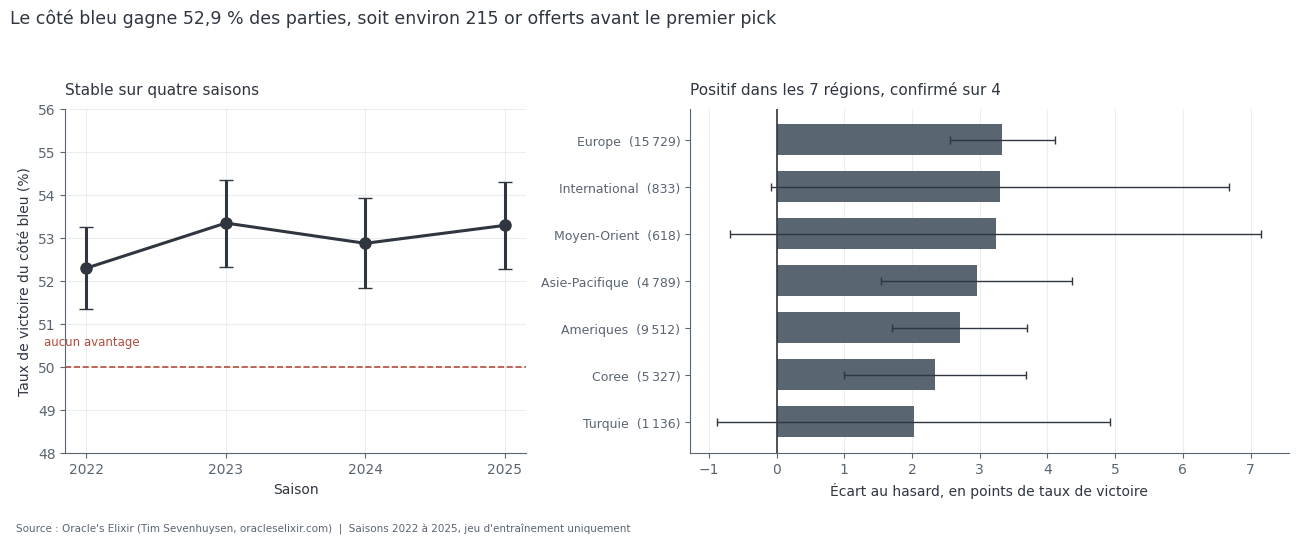

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),
                         gridspec_kw={"width_ratios": [1, 1.3]})

# A gauche, la stabilite dans le temps : une ligne, pas des barres.
ax = axes[0]
saisons = bleu_saison.index.astype(int)
ax.errorbar(saisons, 100 * bleu_saison["taux"],
            yerr=100 * (bleu_saison["ic_haut"] - bleu_saison["ic_bas"]) / 2,
            marker="o", markersize=8, capsize=5, linewidth=2.2, color=PALETTE["primary"])
ax.axhline(50, color=PALETTE["highlight"], linestyle="--", linewidth=1.2)
ax.text(saisons[0] - 0.3, 50.5, "aucun avantage", fontsize=8.5, color=PALETTE["highlight"])
ax.set_xticks(saisons)
ax.set_ylim(48, 56)
ax.set_xlabel("Saison")
ax.set_ylabel("Taux de victoire du côté bleu (%)")
ax.set_title("Stable sur quatre saisons", fontsize=11, pad=10, loc="left")
ax.grid(True, alpha=0.5)

# A droite, l'ecart au hasard par region : barres centrees sur zero.
ax = axes[1]
ecarts = 100 * (bleu_region["taux"] - 0.5)
couleurs = [PALETTE["secondary"] if e > 0 else PALETTE["highlight"] for e in ecarts]
y = np.arange(len(ecarts))
ax.barh(y, ecarts, color=couleurs, height=0.66,
        xerr=100 * (bleu_region["ic_haut"] - bleu_region["ic_bas"]) / 2,
        error_kw={"ecolor": PALETTE["primary"], "capsize": 3, "lw": 1})
ax.axvline(0, color=PALETTE["primary"], linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels([f"{region}  ({fr(n)})"
                    for region, n in zip(bleu_region.index, bleu_region["effectif"])],
                   fontsize=9)
ax.set_xlabel("Écart au hasard, en points de taux de victoire")
# Le signe est positif partout, mais l'intervalle n'exclut zero que sur les regions les
# plus fournies. Le titre le dit plutot que de laisser croire a une confirmation generale.
exclut_zero = int((bleu_region["ic_bas"] > 0.5).sum())
ax.set_title(f"Positif dans les {len(bleu_region)} régions, confirmé sur {exclut_zero}",
             fontsize=11, pad=10, loc="left")
ax.grid(True, axis="x", alpha=0.5)

fig.suptitle(f"Le côté bleu gagne {nb(100 * bleu['result'].mean())} % des parties, "
             f"soit environ {fr((bleu['result'].mean() - 0.5) / pente)} or offerts avant "
             "le premier pick",
             fontsize=12.5, y=1.05, x=0.005, ha="left")
fig.tight_layout()
viz.signer(fig, y=-0.02)
viz.enregistrer(fig, "06_avantage_cote_bleu.png")
plt.show()

Un avantage de 2,9 points, dont l'intervalle de confiance ne touche pas 50 %, et qui ne dérive
pas d'une saison à l'autre. Pour la modélisation, c'est le profil idéal : un effet faible mais
stable traverse sans dommage la frontière du split chronologique.

**Une nuance que le panneau de droite impose.** L'écart est positif dans les sept régions
retenues, mais l'intervalle de confiance n'exclut zéro que dans les quatre régions les plus
fournies. Pour la Turquie, le Moyen-Orient et les tournois internationaux, l'effectif ne permet
pas de conclure séparément. Le titre du panneau le dit explicitement plutôt que de laisser
croire à une confirmation générale : sept barres positives ne font pas sept confirmations.

### 4.4 Les figures des questions 2, 3 et 5 en une phrase

Deux résultats négatifs et un résultat faible mais solide. Ce sont les moins spectaculaires du
projet et les plus utiles à un staff, parce qu'ils indiquent où ne pas dépenser d'attention.

## 5. Acte 4 : où se joue vraiment la partie

### 5.1 La distribution des écarts, et les trois régimes

**Message.** Un tiers des parties est déjà pliée, un tiers est encore ouverte, et c'est sur
celui-là que se joue la valeur d'un modèle.

Histogramme : le type recommandé pour montrer une distribution. Les trois régimes sont
matérialisés par des zones plutôt que par un découpage arbitraire des barres.

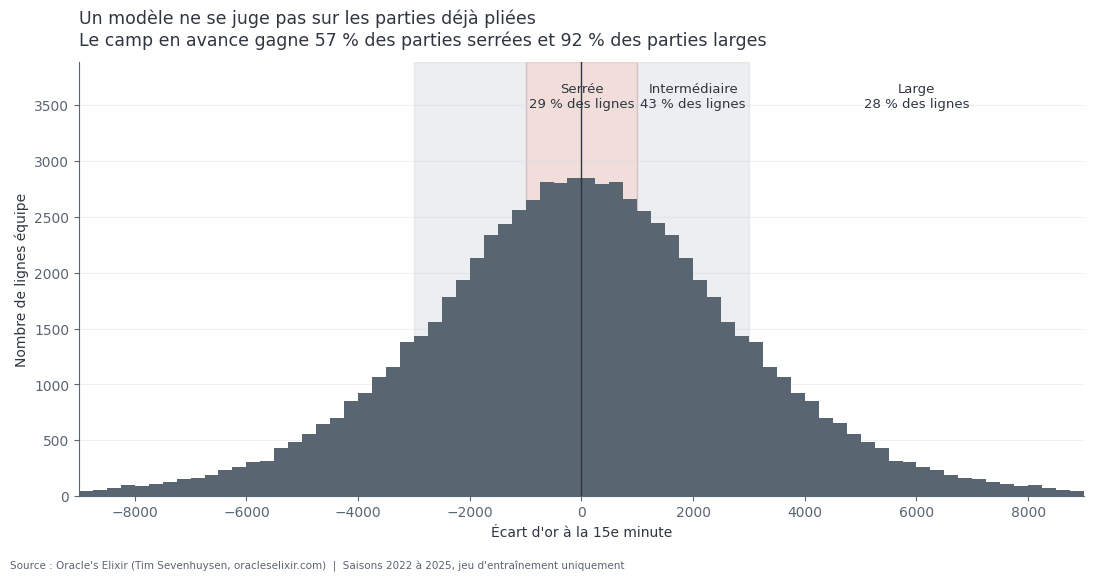

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.6))

ax.hist(train["golddiffat15"], bins=np.arange(-9000, 9001, 250),
        color=PALETTE["secondary"], edgecolor="none")

ymax = ax.get_ylim()[1]
for debut, fin, couleur, alpha in [
    (-SEUIL_SERRE, SEUIL_SERRE, PALETTE["highlight"], 0.18),
    (-SEUIL_LARGE, -SEUIL_SERRE, PALETTE["accent"], 0.16),
    (SEUIL_SERRE, SEUIL_LARGE, PALETTE["accent"], 0.16),
]:
    ax.axvspan(debut, fin, color=couleur, alpha=alpha, zorder=0)

# Les etiquettes ne portent que le nom et la part. Les taux de conversion sont dans le
# titre : trois blocs de trois lignes se chevaucheraient au centre, ou la distribution
# est la plus dense.
for x, nom, ligne in [(0, "Serrée", regimes.loc[0]),
                      (2000, "Intermédiaire", regimes.loc[1]),
                      (6000, "Large", regimes.loc[2])]:
    ax.text(x, ymax * 1.24, f"{nom}\n{nb(ligne['part_pct'], 0)} % des lignes",
            ha="center", va="top", fontsize=9.5, color=PALETTE["primary"])

ax.axvline(0, color=PALETTE["primary"], linewidth=1)
ax.set_xlim(-9000, 9000)
ax.set_ylim(0, ymax * 1.3)
ax.set_xlabel("Écart d'or à la 15e minute")
ax.set_ylabel("Nombre de lignes équipe")
ax.set_title("Un modèle ne se juge pas sur les parties déjà pliées\n"
             f"Le camp en avance gagne "
             f"{nb(regimes.loc[0, 'taux_du_camp_en_avance'], 0)} % des parties serrées "
             f"et {nb(regimes.loc[2, 'taux_du_camp_en_avance'], 0)} % des parties larges",
             fontsize=12.5, pad=12, loc="left")
ax.grid(True, axis="y", alpha=0.45)

fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "06_trois_regimes_de_partie.png")
plt.show()

La distribution est symétrique, comme elle doit l'être : chaque partie fournit une ligne portant
l'écart et une portant son opposé. L'écart médian en valeur absolue est d'environ 1 800 or.

Ce découpage cadre l'attente de la phase 7. Les 28 % de lignes à plus de 3 000 or d'écart se
prédisent à 92 % sans aucun modèle. Les 29 % de lignes serrées plafonnent à 57 % pour la
meilleure règle simple disponible. Une accuracy globale de 72 à 78 % est donc le domaine
plausible, et un score nettement au-dessus devrait faire chercher une fuite plutôt que se fêter.

### 5.2 La forme récente, question business 4

**Message.** La forme pèse plus quand la partie est serrée que lorsqu'une avance est prise. Elle
mesure le niveau de l'équipe, pas une capacité à conclure.

Lignes multiples, trois séries : c'est la limite recommandée par le guide. L'amplitude de chaque
courbe est écrite dans la légende, parce que c'est la comparaison des amplitudes, et non leur
niveau, qui porte l'insight.

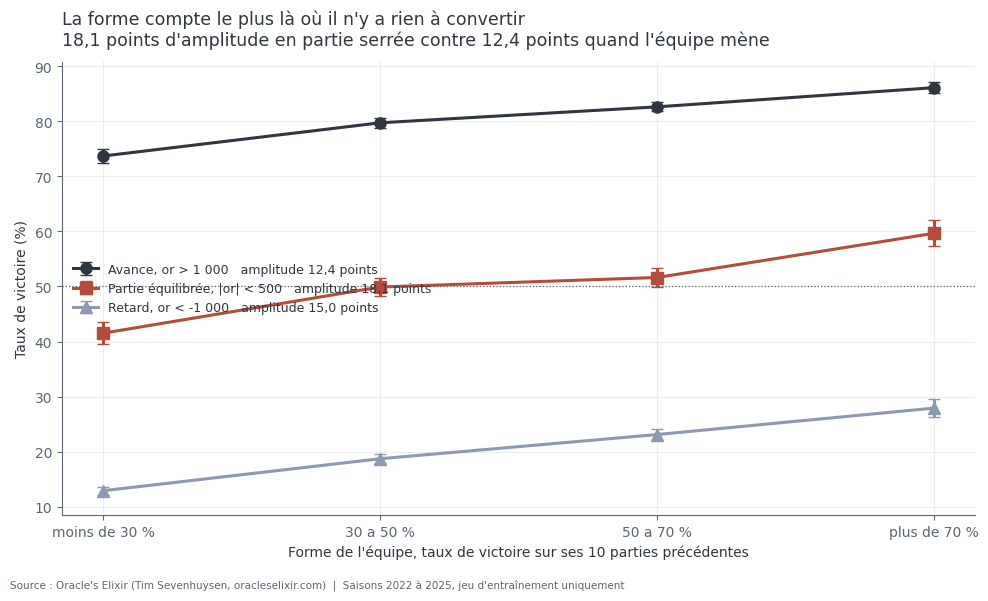

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.8))

styles = {
    "Avance, or > 1 000": (PALETTE["primary"], "o"),
    "Partie équilibrée, |or| < 500": (PALETTE["highlight"], "s"),
    "Retard, or < -1 000": (PALETTE["accent"], "^"),
}
x = np.arange(len(ETIQUETTES))
amplitudes = {}
for nom, (couleur, marqueur) in styles.items():
    table = forme_tables[nom]
    amplitude = 100 * (table["taux"].iloc[-1] - table["taux"].iloc[0])
    amplitudes[nom] = amplitude
    ax.errorbar(x, 100 * table["taux"],
                yerr=100 * (table["ic_haut"] - table["ic_bas"]) / 2,
                marker=marqueur, markersize=8, capsize=4, linewidth=2.2, color=couleur,
                label=f"{nom}   amplitude {nb(amplitude)} points")

ax.axhline(50, color=PALETTE["secondary"], linestyle=":", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(ETIQUETTES)
ax.set_xlabel("Forme de l'équipe, taux de victoire sur ses 10 parties précédentes")
ax.set_ylabel("Taux de victoire (%)")
ax.set_title("La forme compte le plus là où il n'y a rien à convertir\n"
             f"{nb(amplitudes['Partie équilibrée, |or| < 500'])} points d'amplitude en partie "
             f"serrée contre {nb(amplitudes['Avance, or > 1 000'])} points quand l'équipe mène",
             fontsize=12.5, pad=12, loc="left")
ax.legend(frameon=False, fontsize=9, loc="center left")
ax.grid(True, alpha=0.5)

fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "06_forme_par_regime.png")
plt.show()

Si la forme mesurait une capacité à convertir, la courbe du haut serait la plus pentue, puisque
c'est là qu'il y a quelque chose à convertir. C'est l'inverse. Un avantage de 1 000 or absorbe
une partie de l'écart de niveau : il remonte une équipe en mauvaise forme à 73,7 % de victoire,
ce qu'aucune bonne forme ne lui offrirait dans une partie serrée.

**Limite à dire à l'oral.** La forme récente est confondue avec le niveau de l'équipe, et cette
analyse ne sépare pas les deux. Il faudrait un classement de type Elo, absent des sources.

## 6. Passage à la phase 7 : la redondance entre variables

**Message.** Quatre variables mesurent la même domination économique, et deux sont presque
identiques.

**Audience.** Technique. Cette figure ne sert pas le récit métier, elle prépare une décision de
modélisation.

Carte de chaleur : le type recommandé pour une relation entre nombreuses variables. Palette
divergente, parce que le signe compte autant que l'intensité.

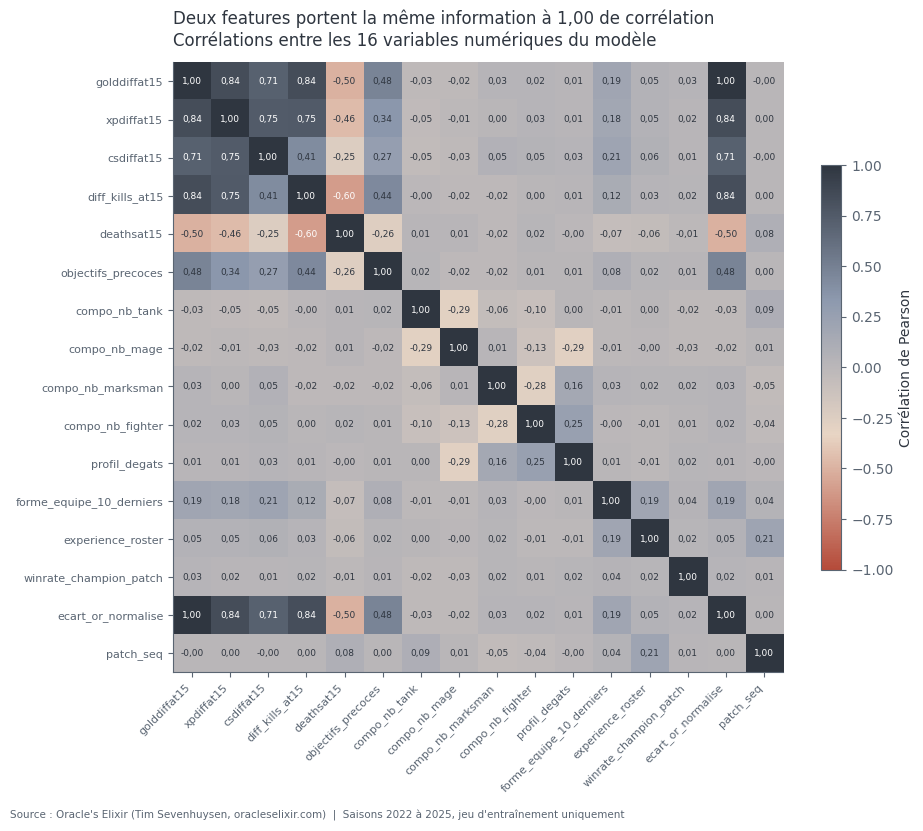

In [13]:
NUMERIQUES = [c for c in config.NUMERIC_FEATURES if c in train.columns]
correlations = train[NUMERIQUES].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
image = ax.imshow(correlations.values, cmap=viz.CMAP_ARDOISE, vmin=-1, vmax=1)

ax.set_xticks(range(len(NUMERIQUES)))
ax.set_xticklabels(NUMERIQUES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(NUMERIQUES)))
ax.set_yticklabels(NUMERIQUES, fontsize=8)

for i in range(len(NUMERIQUES)):
    for j in range(len(NUMERIQUES)):
        valeur = correlations.values[i, j]
        ax.text(j, i, nb(valeur, 2), ha="center", va="center", fontsize=6.5,
                color="white" if abs(valeur) > 0.55 else PALETTE["primary"])

ax.set_title("Deux features portent la même information à 1,00 de corrélation\n"
             "Corrélations entre les 16 variables numériques du modèle",
             fontsize=12, pad=12, loc="left")
fig.colorbar(image, ax=ax, shrink=0.65, label="Corrélation de Pearson")
fig.tight_layout()
viz.signer(fig, y=-0.01)
viz.enregistrer(fig, "06_redondance_features.png")
plt.show()

In [14]:
# Les couples les plus redondants, a garder sous la main pour la phase 7.
triangle = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
couples = triangle.stack().sort_values(key=abs, ascending=False).head(6)
print("Couples de variables les plus correles :")
for (a, b), valeur in couples.items():
    print(f"  {a:26s} {b:26s} {valeur:+.4f}")

Couples de variables les plus correles :
  golddiffat15               ecart_or_normalise         +0.9999
  golddiffat15               xpdiffat15                 +0.8403
  xpdiffat15                 ecart_or_normalise         +0.8395
  golddiffat15               diff_kills_at15            +0.8365
  diff_kills_at15            ecart_or_normalise         +0.8358
  xpdiffat15                 diff_kills_at15            +0.7533


`golddiffat15` et `ecart_or_normalise` corrèlent à 1,00 une fois arrondi : la seconde est la
première divisée par une médiane de patch qui bouge lentement. Quatre autres couples dépassent
0,70, tous entre écarts économiques.

**Conséquence pour la phase 7.** Une régression logistique sur ces variables aura des
coefficients instables et difficiles à interpréter, ce qui est gênant puisque c'est le modèle
choisi comme référence explicable. Trois options se présentent : garder les deux et régulariser
en L2, ne garder que la version normalisée qui traverse mieux la frontière du split, ou comparer
les deux configurations. La décision se prendra en phase 7, sur la validation croisée du jeu
d'entraînement, jamais sur le test.

Les modèles à base d'arbres, forêt aléatoire et gradient boosting, n'en souffrent pas : la
redondance y coûte de l'importance diluée entre deux colonnes, pas de la performance.

## 7. Documentation des visualisations

Le guide demande une fiche par figure. Le tableau ci-dessous la produit à partir du dossier
`figures/` réellement écrit, et une assertion échoue si une fiche décrit une figure absente.

In [15]:
FICHES = [
    {"fichier": "06_tableau_de_bord.png", "question": "Vue d'ensemble",
     "type": "Tableau de bord, tuiles plus courbe plus barres",
     "message": "Quatre chiffres a retenir et la relation qui structure le projet",
     "audience": "Direction sportive, producteur"},
    {"fichier": "06_hierarchie_avantages.png", "question": "Question 1",
     "type": "Barres horizontales triees",
     "message": "Le classement brut place les objectifs precoces loin derriere l'or",
     "audience": "Analyste, casteur"},
    {"fichier": "06_illusion_des_objectifs.png", "question": "Question 1",
     "type": "Barres groupees, contraste",
     "message": "A or egal le classement s'inverse : le dragon vaut 1 030 or, les autres zero",
     "audience": "Coach, analyste"},
    {"fichier": "06_avantage_cote_bleu.png", "question": "Question 2",
     "type": "Ligne temporelle plus barres d'ecart au hasard",
     "message": "Un avantage de 2,9 points, faible mais stable sur quatre saisons",
     "audience": "Coach, staff de draft"},
    {"fichier": "06_composition_sans_effet.png", "question": "Question 3",
     "type": "Petits multiples, points et intervalles",
     "message": "Aucune composition ne sort du hasard une fois l'or neutralise",
     "audience": "Staff de draft"},
    {"fichier": "06_forme_par_regime.png", "question": "Question 4",
     "type": "Lignes multiples, trois series",
     "message": "La forme mesure le niveau de l'equipe, pas une capacite a conclure",
     "audience": "Coach, preparateur mental"},
    {"fichier": "06_ligues_conversion.png", "question": "Question 5",
     "type": "Barres groupees depuis zero",
     "message": "Le niveau de ligue ne change pas la valeur d'une avance precoce",
     "audience": "Recrutement, scouting"},
    {"fichier": "06_trois_regimes_de_partie.png", "question": "Transversale",
     "type": "Histogramme avec zones",
     "message": "Un tiers des parties est deja pliee, un tiers est encore indecise",
     "audience": "Analyste, jury technique"},
    {"fichier": "06_redondance_features.png", "question": "Preparation phase 7",
     "type": "Carte de chaleur divergente",
     "message": "Deux features portent la meme information a 1,00 de correlation",
     "audience": "Technique"},
]

fiches = pd.DataFrame(FICHES)
fiches["poids_ko"] = [
    round((config.FIGURES / f).stat().st_size / 1000) if (config.FIGURES / f).exists() else 0
    for f in fiches["fichier"]
]

manquantes = fiches.loc[fiches["poids_ko"] == 0, "fichier"].tolist()
assert not manquantes, f"Figures documentees mais absentes du dossier : {manquantes}"

print(f"{len(fiches)} figures produites par ce notebook")
print(fiches[["fichier", "question", "type", "poids_ko"]].to_string(index=False))

9 figures produites par ce notebook
                       fichier            question                                            type  poids_ko
        06_tableau_de_bord.png      Vue d'ensemble Tableau de bord, tuiles plus courbe plus barres       190
   06_hierarchie_avantages.png          Question 1                      Barres horizontales triees       101
 06_illusion_des_objectifs.png          Question 1                      Barres groupees, contraste        81
     06_avantage_cote_bleu.png          Question 2  Ligne temporelle plus barres d'ecart au hasard       113
 06_composition_sans_effet.png          Question 3         Petits multiples, points et intervalles        83
       06_forme_par_regime.png          Question 4                  Lignes multiples, trois series       111
      06_ligues_conversion.png          Question 5                     Barres groupees depuis zero        83
06_trois_regimes_de_partie.png        Transversale                          Histogramme avec

In [16]:
toutes = sorted(p.name for p in config.FIGURES.glob("*.png"))
print(f"Total du dossier figures/ : {len(toutes)} fichiers, minimum requis 7")
for nom in toutes:
    print(f"  {nom}")

Total du dossier figures/ : 15 fichiers, minimum requis 7
  02_completude_at15_ligue_saison.png
  05_avantage_cote_bleu.png
  05_conversion_ecart_or.png
  05_conversion_par_tier.png
  05_forme_et_conversion.png
  05_valeur_objectifs_precoces.png
  06_avantage_cote_bleu.png
  06_composition_sans_effet.png
  06_forme_par_regime.png
  06_hierarchie_avantages.png
  06_illusion_des_objectifs.png
  06_ligues_conversion.png
  06_redondance_features.png
  06_tableau_de_bord.png
  06_trois_regimes_de_partie.png


## 8. Export de la documentation

In [17]:
def tableau_markdown(df):
    entete = "| " + " | ".join(str(c) for c in df.columns) + " |"
    separateur = "|" + "|".join(["---"] * len(df.columns)) + "|"
    corps = ["| " + " | ".join(str(v) for v in ligne) + " |"
             for ligne in df.itertuples(index=False)]
    return "\n".join([entete, separateur] + corps)


fiches_doc = fiches.rename(columns={
    "fichier": "Fichier", "question": "Question business", "type": "Type de graphique",
    "message": "Message transmis", "audience": "Audience", "poids_ko": "Poids (ko)",
})
inventaire = chr(10).join("- `" + nom + "`" for nom in toutes)

# Les memes formateurs francais que les figures, pour que le document et les images
# n'ecrivent pas le meme nombre de deux facons differentes.
ecart_brut_max = nb(contraste.iloc[0]["ecart_brut"], signe=True)
ecart_propre_max = nb(contraste.iloc[0]["ecart_a_or_egal"], signe=True)
ecart_fb = nb(contraste.loc[contraste["objectif"] == "firstblood",
                            "ecart_a_or_egal"].iloc[0], signe=True)
ecart_dragon = nb(contraste.loc[contraste["objectif"] == "firstdragon",
                                "ecart_a_or_egal"].iloc[0], signe=True)
or_dragon_fr = fr(round(or_dragon, -1))
pente_fr = nb(100 * pente * 1000)
bleu_fr = nb(100 * bleu["result"].mean())
ic_fr = f"[{nb(100 * ic_bas)} ; {nb(100 * ic_haut)}]"
part_serree = nb(regimes.loc[0, "part_pct"], 0)
part_large = nb(regimes.loc[2, "part_pct"], 0)
taux_serree = nb(regimes.loc[0, "taux_du_camp_en_avance"], 0)
taux_large = nb(regimes.loc[2, "taux_du_camp_en_avance"], 0)
ecart_tiers = nb(100 * test_tiers["ecart"], signe=True)
p_tiers = nb(test_tiers["p_valeur"], 2)

document = f"""# Visualisations, phase 6

Document genere par `notebooks/06_visualisation.ipynb`, a ne pas editer a la main.

Donnees fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).
Toutes les figures portent sur les saisons 2022 a 2025, jeu d'entrainement uniquement.
La saison 2026 reste fermee jusqu'a la fin de la phase 7.

## Le fil rouge

Tous les avantages precoces ne se valent pas, et le classement auquel tout le monde se fie est
presque exactement a l'envers. Le premier heraut mene le classement brut avec
{ecart_brut_max} points d'ecart de taux de victoire et ne vaut plus que
{ecart_propre_max} point une fois l'or neutralise. Le premier dragon ferme ce meme
classement et vaut {or_dragon_fr} or.

Le recit se deroule en quatre actes : ce que l'on sait a la 15e minute, le classement trompeur,
la mesure a avantage economique egal, puis les trois regimes de partie qui cadrent ce qu'un
modele peut esperer.

## Regles de design appliquees

| Regle | Application sur ce projet |
|---|---|
| Honnetete des axes | Toute barre part de zero. L'avantage du cote bleu, trop faible pour etre lisible ainsi, est represente comme un ecart au hasard centre sur zero plutot que par une barre tronquee |
| Focus | Ardoise pour le contexte, brique sourde pour l'element a regarder, une seule couleur d'accent par figure |
| Simplicite | Aucun effet de relief, aucun double axe, quatre couleurs au maximum |
| Coherence | Palette et styles centralises dans `src/config.py` et `src/viz.py` |
| Source et periode | Ajoutees automatiquement par `viz.signer` sur chaque figure |

## Fiches par figure

{tableau_markdown(fiches_doc)}

## Chiffres cles portes par les figures

| Chiffre | Valeur | Figure |
|---|---|---|
| Pente de conversion de l'or | {pente_fr} points de taux de victoire pour 1 000 or | `06_tableau_de_bord.png` |
| Valeur reelle du premier dragon | {or_dragon_fr} or, soit {ecart_dragon} points | `06_illusion_des_objectifs.png` |
| Valeur reelle du premier sang | {ecart_fb} point, non significatif | `06_illusion_des_objectifs.png` |
| Avantage du cote bleu | {bleu_fr} % {ic_fr} | `06_avantage_cote_bleu.png` |
| Parties encore serrees a 15 minutes | {part_serree} % des lignes, camp en avance a {taux_serree} % | `06_trois_regimes_de_partie.png` |
| Parties deja pliees | {part_large} % des lignes, camp en avance a {taux_large} % | `06_trois_regimes_de_partie.png` |
| Ecart tier 1 contre tier 3 | {ecart_tiers} point, p = {p_tiers} | `06_ligues_conversion.png` |

## Inventaire du dossier figures/

{len(toutes)} fichiers, pour un minimum requis de 7.

{inventaire}

## Ce que ces figures preparent pour la phase 7

1. L'attente de performance est cadree : {part_large} % des lignes se predisent presque seules
   et {part_serree} % restent indecises, ce qui rend plausible une accuracy de 72 a 78 % et
   suspect tout score nettement superieur.
2. Une redondance forte est documentee entre `golddiffat15` et `ecart_or_normalise`. La
   regression logistique devra etre regularisee, ou l'une des deux variables retiree, decision a
   prendre sur la validation croisee du train.
3. Les variables de composition n'apportent rien en univarie ni a or egal. Elles restent au
   premier tour et sont les premieres candidates au retrait.
"""

chemin = config.DOCS / "visualisations.md"
chemin.write_text(document, encoding="utf-8")
print(f"Documentation ecrite : {chemin}")
print(f"{len(document):,} caracteres".replace(",", " "))

Documentation ecrite : E:\LWP(LoLWinPrediciton)\lol-win-prediction\docs\visualisations.md
5 258 caracteres


## 9. Validation de la phase

### Checklist du guide

| Point | État |
|---|---|
| Au moins 5 à 7 visualisations produites | 9 figures dans ce notebook, 15 dans `figures/` |
| Chaque question business a une visualisation | Questions 1 à 5 couvertes, plus deux figures transversales |
| Un tableau de bord ou une vue d'ensemble existe | `06_tableau_de_bord.png` |
| Chaque visualisation a un titre clair | Titres formulés comme un message, pas comme une étiquette |
| Axes labellisés avec unités | Points de taux de victoire, or, nombre de lignes |
| Sources et périodes indiquées | Ajoutées par `viz.signer` sur les neuf figures |
| Pas de relief, pas d'axe tronqué sur des barres | Vérifié, l'écart au hasard remplace la barre tronquée |
| Un fil narratif relie les visualisations | Quatre actes, énoncés en tête de notebook |

### Le test des cinq secondes

Chaque titre énonce la conclusion plutôt que le contenu. Un lecteur qui ne voit que les titres
des neuf figures reçoit déjà le récit complet.

1. Prédire une partie professionnelle à la 15e minute
2. Les objectifs précoces arrivent loin derrière les écarts économiques
3. Le premier héraut mène le classement brut et ne vaut rien, le dragon le ferme et vaut 1 030 or
4. Le côté bleu gagne 52,9 % des parties
5. Aucune composition ne sort du hasard une fois l'or neutralisé
6. La forme compte le plus là où il n'y a rien à convertir
7. Le niveau de ligue ne change pas la valeur d'une avance précoce
8. Un modèle ne se juge pas sur les parties déjà pliées
9. Deux features portent la même information

### Limites assumées

**Aucune carte géographique.** Le guide la cite comme type de graphique, mais la variable
géographique de ce projet est une région de circuit compétitif, pas un territoire. Une carte
suggérerait une lecture spatiale qui n'a pas de sens ici, et la lecture par barres est plus
honnête.

**Aucun camembert.** Le seul candidat était la répartition des trois régimes de partie, et le
guide recommande les barres dès que la comparaison des parts compte plus que le fait qu'elles
totalisent 100 %. C'est le cas ici, puisque chaque régime porte aussi un taux de conversion.

**Les figures de la phase 5 restent en place.** Elles servent un autre usage, la démonstration
analytique, et leurs titres décrivent au lieu de conclure. Les deux jeux coexistent
volontairement.

## 10. Réflexion

**La visualisation la plus impactante.** `06_illusion_des_objectifs.png`, sans hésitation. Elle
tient parce qu'elle utilise le contraste : la même quantité, mesurée deux fois, dont une barre
s'effondre et une autre tient. Aucun texte n'est nécessaire pour comprendre qu'il s'est passé
quelque chose, et l'explication mécanique, un objectif qui rapporte de l'or contre un qui n'en
rapporte pas, se dit en une phrase.

**La plus difficile à concevoir.** Celle du côté bleu. Un écart de trois points sur une échelle
partant de zéro est invisible, et une barre tronquée est exactement la mauvaise pratique que le
guide interdit. La sortie a été de changer la quantité représentée plutôt que l'échelle : un
écart au hasard, centré sur zéro, reste honnête et devient lisible.

**Ce que je ferais différemment avec plus de temps.** Une version en petits multiples par patch
de la courbe de conversion, pour montrer si la valeur de l'or dérive avec le méta. La question a
été laissée de côté parce qu'elle demande de découper 90 patchs, ce qui fait tomber les
effectifs par groupe sous le seuil où un intervalle de confiance reste utile.

**Le fil rouge en une phrase, pour la soutenance.** Le classement des avantages précoces auquel
tout le monde se fie est presque exactement à l'envers, et il suffit de comparer à or égal pour
le voir.

**Ce que la phase 7 doit vérifier.** Que le modèle ne dépasse pas nettement 78 % d'accuracy, que
les coefficients de la régression logistique restent lisibles malgré la redondance mesurée en
section 6, et que `firstdragon` ressorte bien devant `firstblood` dans l'importance des
variables. Si ce n'est pas le cas, c'est le récit de ce notebook qu'il faudra corriger, pas les
chiffres du modèle.